# HEART DISEASE PREDICTION USING MACHINE LEARNING

### LIBRARIES IMPORT AND DATASET VIEWING

In [23]:
# Firstly, lets keep all imported libraties here
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Now, I will load the dataset and try to see the first few rows
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### EXPLORATORY DATA ANALYSIS

In [25]:
# Now let me do a quick EDA like showing summary statistics, checking for missing values and duplicates, plotting correlation maps, and also checking the distribution of any target variable

# General info
df.info()

# Quick statistical summary
df.describe()

# Missing values
print(df.isnull().sum())

# Duplicates
print("Number of duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Number 

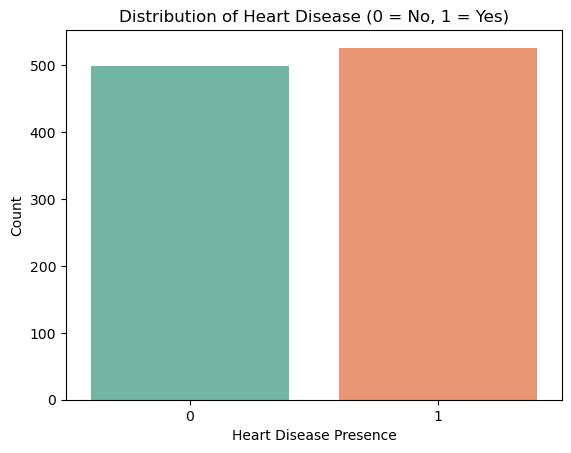

In [32]:
sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)
plt.title("Distribution of Heart Disease (0 = No, 1 = Yes)")
plt.xlabel("Heart Disease Presence")
plt.ylabel("Count")
plt.show()

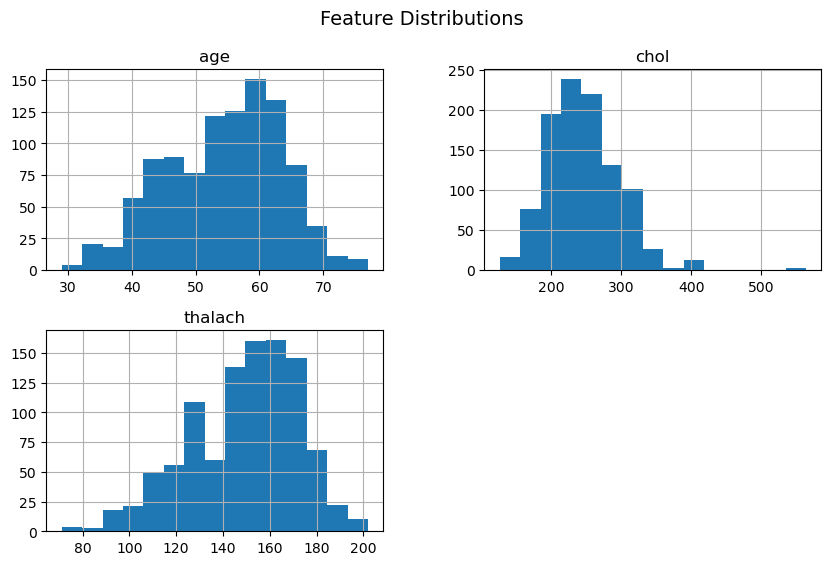

In [27]:
features = ['age', 'chol', 'thalach']
df[features].hist(bins=15, figsize=(10,6))
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Heart Disease Features')

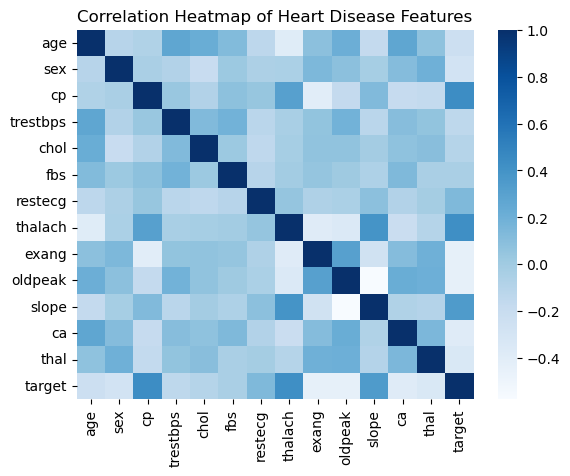

In [28]:
sns.heatmap(df.corr(), cmap="Blues")
plt.title("Correlation Heatmap of Heart Disease Features")

### MODEL TRAINING

In [29]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred = model.predict(X_test)
tb = classification_report(y_test, y_pred, output_dict = True)
tb_disp = pd.DataFrame(tb).transpose()
display(tb_disp)
print("Accuracy:", accuracy_score(y_test, y_pred))

,precision,recall,f1-score,support
0,0.848837,0.715686,0.776596,102.000000
1,0.756303,0.873786,0.810811,103.000000
accuracy,0.795122,0.795122,0.795122,0.795122
macro avg,0.802570,0.794736,0.793703,205.000000
weighted avg,0.802344,0.795122,0.793787,205.000000


Accuracy: 0.7951219512195122


Text(0.5, 1.0, 'Predicted Outcomes (0 = No Disease, 1 = Disease)')

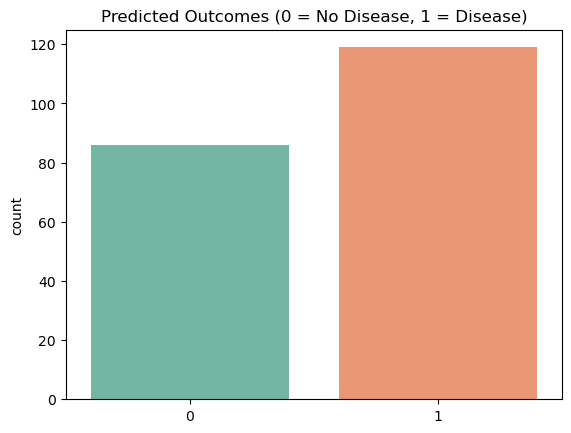

In [31]:
sns.countplot(x=y_pred, hue=y_pred, palette='Set2', legend=False)
plt.title("Predicted Outcomes (0 = No Disease, 1 = Disease)")

### FEATURE IMPORTANCE

Text(0.5, 1.0, 'Top Features Affecting Heart Disease Prediction')

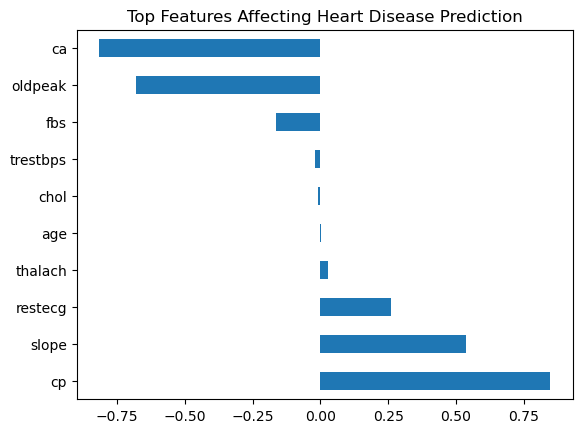

In [33]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Heart Disease Prediction")

# SUMMARY OF FINDINGS

The project used the Heart Disease dataset (1,025 patient records with 14 features) to predict the presence of heart disease using a logistic regression model.

### Exploratory Data Analysis (EDA) revealed:
The dataset has no missing values.
About half of the patients in the dataset were diagnosed with heart disease.
Features such as chest pain type (cp), maximum heart rate achieved (thalach), and exercise-induced angina (exang) were strongly correlated with heart disease presence.
Cholesterol (chol) and fasting blood sugar (fbs) showed weaker correlation.

### Model Results:
The logistic regression model achieved an accuracy of 79.5% on the test data.
Precision and recall were balanced for both classes (no-disease vs disease).

### Top predictive features included:
Chest pain type (cp)
Exercise-induced angina (exang)
Maximum heart rate (thalach)
ST depression (oldpeak)
The slope of the peak exercise segment (slope)

### Interpretation:
This means the model can correctly predict around 8 out of 10 patients based on their health indicators. Features like chest pain and exercise results strongly influence the likelihood of heart disease.

### Conclusion:
Machine learning can be a valuable tool for early detection and prevention of heart-related conditions.
Although this model is basic, it shows the potential of data-driven systems to support clinical decision-making and public health planning.

So, what I did here was take a public dataset that contains information about patients — things like their age, cholesterol, heart rate, and so on and tried to predict if they have heart disease or not.
First, I cleaned and checked the data to make sure there were no missing or duplicate records. Then I looked at patterns, for example, people with certain chest pain types or lower maximum heart rates seemed more likely to have heart disease.

I used a simple machine learning model called logistic regression, which basically tries to find patterns that separate people with heart disease from those without it. After training and testing it, the model was about 80% accurate, meaning it got 8 out of 10 predictions right.
The most important factors turned out to be chest pain type, exercise-related results, and ST depression levels. This makes sense because those are real indicators doctors use.

So overall, this small project shows that even simple AI models can help spot heart disease early, which could be really useful in health informatics.